# Nonuniform HSBM fixed-n K-scaling spectral clustering

This notebook fixes `n`, varies the number of communities `K`, generates non-uniform HSBM hypergraphs with `generate_nonuniform_hsbm_instance`, and runs spectral clustering with the Zhou normalized hypergraph Laplacian.

Each experiment cell below runs a different `K`. Edit `N_FIXED`, `K_VALUES`, or `CONFIG` to change the sweep.


In [1]:
from pathlib import Path
import gc
import json
import math
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_nonuniform_hsbm_instance,
    make_sparse_hsbm_probs,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260426-003"
EXPERIMENT_SLUG = "nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian"
OUTDIR = PROJECT_ROOT / "experiments" / "\uba54\uc778 \uc2e4\ud5d8" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR

('EXP-20260426-003',
 'nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian',
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian'))

## Configuration

`make_sparse_hsbm_probs` maps the constant-scale parameters below to `p_in[m] = a_in[m] / n ** (m - 1)` and `p_out[m] = b_out[m] / n ** (m - 1)`. This keeps the expected number of hyperedges roughly linear in `n`.

In [2]:
CONFIG = {
    "K": 3,
    "m_values": [2, 3],
    "a_in": {2: 24.0, 3: 36.0},
    "b_out": {2: 3.0, 3: 4.0},
    "reps": 10,
    "seed": 20260425,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

N_FIXED = 5000
K_VALUES = [2, 3, 4, 5, 6, 8, 10]

CONFIG, N_FIXED, K_VALUES

({'K': 3,
  'm_values': [2, 3],
  'a_in': {2: 24.0, 3: 36.0},
  'b_out': {2: 3.0, 3: 4.0},
  'reps': 10,
  'seed': 20260425,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 5000,
 [2, 3, 4, 5, 6, 8, 10])

## Helpers

In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_laplacian(L, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(L.shape[0])
    L = ((L + L.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    if n <= K + 1:
        vals, vecs = np.linalg.eigh(L.toarray())
        order = np.argsort(vals)[:K]
        U = vecs[:, order]
    else:
        try:
            v0 = rng.normal(size=n)
            vals, vecs = spla.eigsh(L, k=K, which="SA", tol=eigsh_tol, v0=v0)
            order = np.argsort(vals)
            U = vecs[:, order]
        except Exception as exc:
            warnings.warn(f"eigsh failed ({exc}); falling back to dense eigh.")
            vals, vecs = np.linalg.eigh(L.toarray())
            order = np.argsort(vals)[:K]
            U = vecs[:, order]
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_laplacian_nnz": int(L.nnz),
        **timings,
    }


def run_one_rep(n, rep, config):
    K = int(config["K"])
    m_values = [int(m) for m in config["m_values"]]
    seed = int(config["seed"] + 1_000_003 * int(n) + 10_007 * K + int(rep))
    rng = np.random.default_rng(seed)
    p_in, p_out = make_sparse_hsbm_probs(
        n=n,
        m_values=m_values,
        a_in=config["a_in"],
        b_out=config["b_out"],
    )

    timings = {}
    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_nonuniform_hsbm_instance(
        n=n,
        K=K,
        m_values=m_values,
        p_in=p_in,
        p_out=p_out,
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
    )
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    timings["zhou_laplacian_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_laplacian(
        L=L,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": int(n),
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m_values": ",".join(str(m) for m in m_values),
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_laplacian_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )

    per_size = gen_stats.get("per_size", {})
    for m in m_values:
        stats_m = per_size.get(str(m), {})
        record[f"p_in_m{m}"] = float(p_in[m])
        record[f"p_out_m{m}"] = float(p_out[m])
        record[f"num_edges_m{m}"] = int(stats_m.get("num_hyperedges", stats_m.get("num_edges", 0)))
        record[f"sampling_m{m}"] = stats_m.get("sampling_mode", "")

    return record


def run_one_rep_measured(n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(n, rep, config))
    record.update(measurement)
    return record


def run_k_experiment(K, n=None, reps=None, config=None):
    if config is None:
        config = CONFIG
    if n is None:
        n = N_FIXED

    cfg = dict(config)
    cfg["K"] = int(K)
    if reps is None:
        reps = int(cfg["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(n=n, rep=rep, config=cfg)
        rows.append(row)
        print(
            f"K={K:2d} n={n:5d} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:6d} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"eig={row['eigen_decomposition_wall_sec']:.3f}s "
            f"km={row['kmeans_wall_sec']:.3f}s "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_k(df_raw):
    return df_raw.groupby("K", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        generation_wall_sec_std=("generation_wall_sec", "std"),
        zhou_laplacian_wall_sec_mean=("zhou_laplacian_wall_sec", "mean"),
        zhou_laplacian_wall_sec_std=("zhou_laplacian_wall_sec", "std"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        eigen_decomposition_wall_sec_std=("eigen_decomposition_wall_sec", "std"),
        embedding_normalize_wall_sec_mean=("embedding_normalize_wall_sec", "mean"),
        embedding_normalize_wall_sec_std=("embedding_normalize_wall_sec", "std"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        kmeans_wall_sec_std=("kmeans_wall_sec", "std"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        spectral_clustering_wall_sec_std=("spectral_clustering_wall_sec", "std"),
        metric_wall_sec_mean=("metric_wall_sec", "mean"),
        metric_wall_sec_std=("metric_wall_sec", "std"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        algorithm_total_wall_sec_std=("algorithm_total_wall_sec", "std"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        cpu_time_sec_std=("cpu_time_sec", "std"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        wall_clock_sec_std=("wall_clock_sec", "std"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        peak_traced_memory_mb_std=("peak_traced_memory_mb", "std"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
        rss_delta_mb_std=("rss_delta_mb", "std"),
    )

## K = 2

In [4]:
df_k2 = run_k_experiment(2)

K= 2 n= 5000 rep= 1/10 edges= 43747 mis=0.0000 ARI=1.0000 NMI=1.0000 eig=0.019s km=1.413s wall=4.061s peak=13.3MB
K= 2 n= 5000 rep= 2/10 edges= 43826 mis=0.0004 ARI=0.9984 NMI=0.9953 eig=0.012s km=0.028s wall=2.559s peak=13.3MB
K= 2 n= 5000 rep= 3/10 edges= 44005 mis=0.0002 ARI=0.9992 NMI=0.9975 eig=0.012s km=0.028s wall=2.542s peak=13.4MB
K= 2 n= 5000 rep= 4/10 edges= 43416 mis=0.0002 ARI=0.9992 NMI=0.9975 eig=0.012s km=0.029s wall=2.532s peak=13.2MB
K= 2 n= 5000 rep= 5/10 edges= 43629 mis=0.0000 ARI=1.0000 NMI=1.0000 eig=0.012s km=0.028s wall=2.507s peak=13.3MB
K= 2 n= 5000 rep= 6/10 edges= 43620 mis=0.0002 ARI=0.9992 NMI=0.9975 eig=0.012s km=0.033s wall=2.501s peak=13.2MB
K= 2 n= 5000 rep= 7/10 edges= 43646 mis=0.0000 ARI=1.0000 NMI=1.0000 eig=0.012s km=0.028s wall=2.536s peak=13.2MB
K= 2 n= 5000 rep= 8/10 edges= 43626 mis=0.0004 ARI=0.9984 NMI=0.9949 eig=0.012s km=0.030s wall=2.574s peak=13.3MB
K= 2 n= 5000 rep= 9/10 edges= 43710 mis=0.0006 ARI=0.9976 NMI=0.9928 eig=0.012s km=0.029

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020295440,2,"2,3",43747,0.0000,1.000000,1.000000,2.273784,0.149363,1.432201,0.029442,0,19.5256,37.0,132664,0.018573,0.000194,1.413426,3.855340,0.0048,0.0006,33613,sparse,0.000001,1.600000e-07,10134,sparse,3.359375,4.060822,13.321421,201.585938,211.710938,10.125000
1,5000,2,5020295441,2,"2,3",43826,0.0004,0.998400,0.995308,2.176759,0.137964,0.040274,0.029063,0,19.5326,38.0,132350,0.012206,0.000099,0.027962,2.354990,0.0048,0.0006,33815,sparse,0.000001,1.600000e-07,10011,sparse,3.171875,2.558647,13.293872,211.710938,211.406250,-0.304688
2,5000,3,5020295442,2,"2,3",44005,0.0002,0.999200,0.997454,2.148539,0.138683,0.040969,0.032137,0,19.6378,38.0,133360,0.012404,0.000103,0.028457,2.328186,0.0048,0.0006,33826,sparse,0.000001,1.600000e-07,10179,sparse,3.093750,2.542177,13.362414,211.406250,212.988281,1.582031
3,5000,4,5020295443,2,"2,3",43416,0.0002,0.999200,0.997454,2.132642,0.136844,0.041596,0.027310,0,19.3308,37.0,130722,0.012356,0.000101,0.029134,2.311077,0.0048,0.0006,33594,sparse,0.000001,1.600000e-07,9822,sparse,3.125000,2.532187,13.165595,212.988281,212.765625,-0.222656
4,5000,5,5020295444,2,"2,3",43629,0.0000,1.000000,1.000000,2.126379,0.134655,0.040314,0.029484,0,19.4816,39.0,132536,0.012224,0.000099,0.027985,2.301342,0.0048,0.0006,33479,sparse,0.000001,1.600000e-07,10150,sparse,3.015625,2.506863,13.259550,212.765625,211.769531,-0.996094
5,5000,6,5020295445,2,"2,3",43620,0.0002,0.999200,0.997454,2.109698,0.137606,0.045745,0.027589,0,19.4462,37.0,131846,0.012382,0.000126,0.033232,2.293044,0.0048,0.0006,33629,sparse,0.000001,1.600000e-07,9991,sparse,3.125000,2.501465,13.235830,211.769531,211.859375,0.089844
6,5000,7,5020295446,2,"2,3",43646,0.0000,1.000000,1.000000,2.138884,0.138104,0.040340,0.029410,0,19.4436,38.0,131682,0.012277,0.000107,0.027951,2.317322,0.0048,0.0006,33720,sparse,0.000001,1.600000e-07,9926,sparse,3.109375,2.536270,13.239043,211.859375,212.914062,1.054688
7,5000,8,5020295447,2,"2,3",43626,0.0004,0.998400,0.994908,2.194615,0.136340,0.042571,0.030949,0,19.4840,38.0,132598,0.012438,0.000114,0.030014,2.373520,0.0048,0.0006,33458,sparse,0.000001,1.600000e-07,10168,sparse,3.218750,2.573874,13.262224,212.914062,212.457031,-0.457031
8,5000,9,5020295448,2,"2,3",43710,0.0006,0.997601,0.992762,2.120657,0.134338,0.040992,0.034617,0,19.4730,35.0,131828,0.012113,0.000096,0.028778,2.295981,0.0048,0.0006,33765,sparse,0.000001,1.600000e-07,9945,sparse,3.062500,2.522294,13.254805,212.457031,212.363281,-0.093750
9,5000,10,5020295449,2,"2,3",44153,0.0000,1.000000,1.000000,2.149942,0.134755,0.039989,0.026670,0,19.6474,36.0,132694,0.011887,0.000107,0.027990,2.324681,0.0048,0.0006,34222,sparse,0.000001,1.600000e-07,9931,sparse,3.078125,2.532201,13.375994,212.363281,213.097656,0.734375


## K = 3

In [5]:
df_k3 = run_k_experiment(3)

K= 3 n= 5000 rep= 1/10 edges= 31221 mis=0.0058 ARI=0.9827 NMI=0.9643 eig=0.014s km=0.044s wall=1.801s peak=9.5MB
K= 3 n= 5000 rep= 2/10 edges= 31349 mis=0.0078 ARI=0.9767 NMI=0.9544 eig=0.013s km=0.038s wall=1.916s peak=9.6MB
K= 3 n= 5000 rep= 3/10 edges= 31199 mis=0.0052 ARI=0.9845 NMI=0.9674 eig=0.013s km=0.036s wall=1.860s peak=9.5MB
K= 3 n= 5000 rep= 4/10 edges= 30982 mis=0.0066 ARI=0.9803 NMI=0.9605 eig=0.014s km=0.036s wall=1.848s peak=9.5MB
K= 3 n= 5000 rep= 5/10 edges= 31119 mis=0.0060 ARI=0.9821 NMI=0.9631 eig=0.013s km=0.038s wall=1.878s peak=9.5MB
K= 3 n= 5000 rep= 6/10 edges= 31107 mis=0.0060 ARI=0.9821 NMI=0.9638 eig=0.013s km=0.040s wall=1.846s peak=9.5MB
K= 3 n= 5000 rep= 7/10 edges= 31474 mis=0.0048 ARI=0.9856 NMI=0.9697 eig=0.014s km=0.039s wall=1.898s peak=9.6MB
K= 3 n= 5000 rep= 8/10 edges= 31576 mis=0.0082 ARI=0.9756 NMI=0.9528 eig=0.013s km=0.036s wall=1.906s peak=9.7MB
K= 3 n= 5000 rep= 9/10 edges= 31045 mis=0.0068 ARI=0.9797 NMI=0.9593 eig=0.014s km=0.038s wall=1

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020305447,3,"2,3",31221,0.0058,0.982669,0.964291,1.488263,0.095827,0.058687,0.030018,0,13.7474,28.0,92446,0.014171,0.000099,0.044410,1.642770,0.0048,0.0006,24926,sparse,0.000001,1.600000e-07,6295,sparse,2.359375,1.801064,9.528539,213.527344,213.027344,-0.500000
1,5000,2,5020305448,3,"2,3",31349,0.0078,0.976745,0.954392,1.603063,0.095153,0.051576,0.037358,0,13.8110,30.0,92930,0.013298,0.000099,0.038173,1.749786,0.0048,0.0006,24992,sparse,0.000001,1.600000e-07,6357,sparse,2.546875,1.915515,9.567850,213.027344,213.039062,0.011719
2,5000,3,5020305449,3,"2,3",31199,0.0052,0.984455,0.967360,1.559061,0.095748,0.049960,0.031186,0,13.7402,28.0,92438,0.013485,0.000095,0.036375,1.704764,0.0048,0.0006,24896,sparse,0.000001,1.600000e-07,6303,sparse,2.484375,1.860427,9.523869,213.039062,213.125000,0.085938
3,5000,4,5020305450,3,"2,3",30982,0.0066,0.980303,0.960546,1.543586,0.099126,0.050985,0.031606,0,13.6350,35.0,91604,0.014424,0.000147,0.036409,1.693692,0.0048,0.0006,24771,sparse,0.000001,1.600000e-07,6211,sparse,2.468750,1.848089,9.454290,213.125000,212.800781,-0.324219
4,5000,5,5020305451,3,"2,3",31119,0.0060,0.982077,0.963109,1.568736,0.094915,0.051623,0.032425,0,13.7098,30.0,92302,0.013413,0.000083,0.038122,1.715269,0.0048,0.0006,24808,sparse,0.000001,1.600000e-07,6311,sparse,2.437500,1.878118,9.501273,212.800781,212.847656,0.046875
5,5000,6,5020305452,3,"2,3",31107,0.0060,0.982075,0.963752,1.536698,0.093901,0.053263,0.032165,0,13.6996,28.0,92156,0.013277,0.000081,0.039899,1.683857,0.0048,0.0006,24823,sparse,0.000001,1.600000e-07,6284,sparse,2.453125,1.846035,9.494914,212.847656,212.742188,-0.105469
6,5000,7,5020305453,3,"2,3",31474,0.0048,0.985648,0.969725,1.577160,0.099912,0.053401,0.029850,0,13.8324,32.0,92632,0.013856,0.000116,0.039423,1.730468,0.0048,0.0006,25260,sparse,0.000001,1.600000e-07,6214,sparse,2.593750,1.897641,9.585642,212.742188,212.976562,0.234375
7,5000,8,5020305454,3,"2,3",31576,0.0082,0.975556,0.952764,1.608454,0.095407,0.049472,0.026706,0,13.9292,29.0,93988,0.013369,0.000093,0.036005,1.753328,0.0048,0.0006,25082,sparse,0.000001,1.600000e-07,6494,sparse,2.546875,1.905553,9.650093,212.976562,213.066406,0.089844
8,5000,9,5020305455,3,"2,3",31045,0.0068,0.979705,0.959260,1.531373,0.092872,0.051420,0.032716,0,13.6786,30.0,92174,0.013597,0.000085,0.037731,1.675659,0.0048,0.0006,24742,sparse,0.000001,1.600000e-07,6303,sparse,2.453125,1.830144,9.477495,213.066406,212.921875,-0.144531
9,5000,10,5020305456,3,"2,3",31061,0.0070,0.979103,0.957835,1.531569,0.097435,0.052557,0.032783,0,13.6790,28.0,92038,0.014004,0.000108,0.038438,1.681554,0.0048,0.0006,24788,sparse,0.000001,1.600000e-07,6273,sparse,2.437500,1.829153,9.481977,212.921875,212.800781,-0.121094


## K = 4

In [6]:
df_k4 = run_k_experiment(4)

K= 4 n= 5000 rep= 1/10 edges= 25581 mis=0.0396 ARI=0.8971 NMI=0.8494 eig=0.015s km=0.048s wall=1.529s peak=7.9MB
K= 4 n= 5000 rep= 2/10 edges= 25541 mis=0.0386 ARI=0.8997 NMI=0.8521 eig=0.015s km=0.048s wall=1.575s peak=7.9MB
K= 4 n= 5000 rep= 3/10 edges= 25651 mis=0.0448 ARI=0.8840 NMI=0.8336 eig=0.013s km=0.046s wall=1.586s peak=7.9MB
K= 4 n= 5000 rep= 4/10 edges= 25578 mis=0.0366 ARI=0.9048 NMI=0.8588 eig=0.015s km=0.048s wall=1.587s peak=7.9MB
K= 4 n= 5000 rep= 5/10 edges= 25406 mis=0.0336 ARI=0.9123 NMI=0.8690 eig=0.015s km=0.049s wall=1.575s peak=7.9MB
K= 4 n= 5000 rep= 6/10 edges= 25696 mis=0.0394 ARI=0.8977 NMI=0.8496 eig=0.015s km=0.047s wall=1.597s peak=7.9MB
K= 4 n= 5000 rep= 7/10 edges= 25518 mis=0.0420 ARI=0.8911 NMI=0.8427 eig=0.015s km=0.045s wall=1.577s peak=7.9MB
K= 4 n= 5000 rep= 8/10 edges= 25691 mis=0.0386 ARI=0.8997 NMI=0.8521 eig=0.016s km=0.050s wall=1.555s peak=7.9MB
K= 4 n= 5000 rep= 9/10 edges= 25547 mis=0.0478 ARI=0.8766 NMI=0.8243 eig=0.013s km=0.046s wall=1

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020315454,4,"2,3",25581,0.0396,0.897147,0.849401,1.261220,0.079108,0.063580,0.029244,0,11.2400,24.0,76184,0.015435,0.000095,0.048045,1.403903,0.0048,0.0006,20543,sparse,0.000001,1.600000e-07,5038,sparse,2.234375,1.529224,7.909815,212.886719,211.390625,-1.496094
1,5000,2,5020315455,4,"2,3",25541,0.0386,0.899697,0.852130,1.297188,0.081279,0.063099,0.031743,0,11.2346,32.0,76330,0.015304,0.000100,0.047690,1.441561,0.0048,0.0006,20450,sparse,0.000001,1.600000e-07,5091,sparse,2.281250,1.574928,7.905653,211.390625,215.691406,4.300781
2,5000,3,5020315456,4,"2,3",25651,0.0448,0.884025,0.833594,1.315941,0.077440,0.059047,0.029237,0,11.2518,25.0,76026,0.012995,0.000105,0.045941,1.452422,0.0048,0.0006,20694,sparse,0.000001,1.600000e-07,4957,sparse,2.281250,1.585934,7.920729,215.691406,215.949219,0.257812
3,5000,4,5020315457,4,"2,3",25578,0.0366,0.904758,0.858796,1.302729,0.078982,0.062632,0.028612,0,11.2446,27.0,76314,0.014842,0.000106,0.047679,1.444338,0.0048,0.0006,20511,sparse,0.000001,1.600000e-07,5067,sparse,2.125000,1.586709,7.912196,215.949219,215.382812,-0.566406
4,5000,5,5020315458,4,"2,3",25406,0.0336,0.912315,0.869010,1.293126,0.079610,0.064427,0.033162,0,11.1560,25.0,75600,0.015019,0.000120,0.049281,1.437157,0.0048,0.0006,20438,sparse,0.000001,1.600000e-07,4968,sparse,2.140625,1.574865,7.856733,215.382812,216.093750,0.710938
5,5000,6,5020315459,4,"2,3",25696,0.0394,0.897660,0.849575,1.314426,0.081013,0.062007,0.032792,1,11.2998,24.0,76720,0.015074,0.000107,0.046821,1.457441,0.0048,0.0006,20589,sparse,0.000001,1.600000e-07,5107,sparse,2.265625,1.596547,7.948849,216.093750,215.894531,-0.199219
6,5000,7,5020315460,4,"2,3",25518,0.0420,0.891144,0.842671,1.314358,0.076495,0.060615,0.028947,0,11.2116,28.0,76030,0.015491,0.000115,0.045003,1.451462,0.0048,0.0006,20496,sparse,0.000001,1.600000e-07,5022,sparse,2.296875,1.577213,7.890910,215.894531,216.207031,0.312500
7,5000,8,5020315461,4,"2,3",25691,0.0386,0.899681,0.852060,1.288940,0.078351,0.065339,0.026426,0,11.2740,26.0,76244,0.015538,0.000119,0.049677,1.432625,0.0048,0.0006,20703,sparse,0.000001,1.600000e-07,4988,sparse,2.265625,1.554986,7.933105,216.207031,216.304688,0.097656
8,5000,9,5020315462,4,"2,3",25547,0.0478,0.876589,0.824338,1.299707,0.078732,0.059118,0.026921,0,11.2316,32.0,76248,0.012939,0.000090,0.046084,1.437552,0.0048,0.0006,20483,sparse,0.000001,1.600000e-07,5064,sparse,2.187500,1.572496,7.902669,216.304688,215.406250,-0.898438
9,5000,10,5020315463,4,"2,3",25522,0.0408,0.894130,0.845286,1.342505,0.082147,0.060339,0.029551,0,11.2008,25.0,75794,0.014701,0.000154,0.045478,1.484985,0.0048,0.0006,20562,sparse,0.000001,1.600000e-07,4960,sparse,2.312500,1.623713,7.886546,215.406250,216.035156,0.628906


## K = 5

In [7]:
df_k5 = run_k_experiment(5)

K= 5 n= 5000 rep= 1/10 edges= 22463 mis=0.1210 ARI=0.7207 NMI=0.6692 eig=0.019s km=0.075s wall=1.426s peak=7.0MB
K= 5 n= 5000 rep= 2/10 edges= 22469 mis=0.1182 ARI=0.7265 NMI=0.6748 eig=0.018s km=0.068s wall=1.609s peak=7.0MB
K= 5 n= 5000 rep= 3/10 edges= 22715 mis=0.1140 ARI=0.7353 NMI=0.6825 eig=0.016s km=0.074s wall=1.561s peak=7.1MB
K= 5 n= 5000 rep= 4/10 edges= 22425 mis=0.1156 ARI=0.7319 NMI=0.6799 eig=0.016s km=0.084s wall=1.483s peak=7.0MB
K= 5 n= 5000 rep= 5/10 edges= 22288 mis=0.1208 ARI=0.7206 NMI=0.6687 eig=0.017s km=0.058s wall=1.466s peak=7.0MB
K= 5 n= 5000 rep= 6/10 edges= 22393 mis=0.1114 ARI=0.7409 NMI=0.6887 eig=0.015s km=0.083s wall=1.488s peak=7.0MB
K= 5 n= 5000 rep= 7/10 edges= 22543 mis=0.1314 ARI=0.6985 NMI=0.6472 eig=0.016s km=0.064s wall=1.505s peak=7.1MB
K= 5 n= 5000 rep= 8/10 edges= 22389 mis=0.1190 ARI=0.7246 NMI=0.6725 eig=0.018s km=0.064s wall=1.462s peak=7.0MB
K= 5 n= 5000 rep= 9/10 edges= 22144 mis=0.1060 ARI=0.7525 NMI=0.7009 eig=0.016s km=0.064s wall=1

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020325461,5,"2,3",22463,0.1210,0.720698,0.669166,1.120186,0.070538,0.093972,0.038788,0,9.8686,24.0,67506,0.018996,0.000108,0.074861,1.284688,0.0048,0.0006,18046,sparse,0.000001,1.600000e-07,4417,sparse,2.203125,1.425827,7.042494,216.113281,215.222656,-0.890625
1,5000,2,5020325462,5,"2,3",22469,0.1182,0.726547,0.674840,1.313974,0.080609,0.085412,0.031345,0,9.8702,23.0,67502,0.017665,0.000100,0.067641,1.479990,0.0048,0.0006,18056,sparse,0.000001,1.600000e-07,4413,sparse,2.343750,1.608861,7.040699,215.222656,215.148438,-0.074219
2,5000,3,5020325463,5,"2,3",22715,0.1140,0.735336,0.682497,1.258111,0.073109,0.089559,0.038664,0,9.9864,22.0,68354,0.015923,0.000110,0.073520,1.420772,0.0048,0.0006,18213,sparse,0.000001,1.600000e-07,4502,sparse,2.296875,1.561436,7.119104,215.148438,214.800781,-0.347656
3,5000,4,5020325464,5,"2,3",22425,0.1156,0.731858,0.679898,1.179796,0.073660,0.099947,0.029930,0,9.8658,24.0,67676,0.015784,0.000128,0.084029,1.353397,0.0048,0.0006,17946,sparse,0.000001,1.600000e-07,4479,sparse,2.343750,1.483497,7.040838,214.800781,215.160156,0.359375
4,5000,5,5020325465,5,"2,3",22288,0.1208,0.720572,0.668692,1.184160,0.070684,0.075918,0.038390,0,9.7938,23.0,67080,0.017351,0.000106,0.058456,1.330757,0.0048,0.0006,17895,sparse,0.000001,1.600000e-07,4393,sparse,2.203125,1.465525,6.992310,215.160156,215.046875,-0.113281
5,5000,6,5020325466,5,"2,3",22393,0.1114,0.740909,0.688662,1.176587,0.073890,0.098337,0.032635,0,9.8408,22.0,67392,0.015435,0.000112,0.082784,1.348807,0.0048,0.0006,17975,sparse,0.000001,1.600000e-07,4418,sparse,2.187500,1.488276,7.025148,215.046875,215.156250,0.109375
6,5000,7,5020325467,5,"2,3",22543,0.1314,0.698520,0.647201,1.200768,0.071485,0.079652,0.040546,0,9.9054,22.0,67766,0.015642,0.000106,0.063900,1.351900,0.0048,0.0006,18102,sparse,0.000001,1.600000e-07,4441,sparse,2.296875,1.504656,7.064193,215.156250,215.378906,0.222656
7,5000,8,5020325468,5,"2,3",22389,0.1190,0.724625,0.672534,1.182481,0.071304,0.081516,0.031222,0,9.8282,26.0,67148,0.017684,0.000147,0.063679,1.335296,0.0048,0.0006,18026,sparse,0.000001,1.600000e-07,4363,sparse,2.187500,1.462500,7.016850,215.378906,215.363281,-0.015625
8,5000,9,5020325469,5,"2,3",22144,0.1060,0.752478,0.700881,1.172179,0.073645,0.081051,0.029327,0,9.7184,23.0,66436,0.016484,0.000111,0.064451,1.326870,0.0048,0.0006,17840,sparse,0.000001,1.600000e-07,4304,sparse,2.156250,1.455890,6.943915,215.363281,214.988281,-0.375000
9,5000,10,5020325470,5,"2,3",22064,0.1110,0.741927,0.689894,1.178758,0.070413,0.082000,0.033296,0,9.6888,24.0,66302,0.015232,0.000118,0.066645,1.331166,0.0048,0.0006,17748,sparse,0.000001,1.600000e-07,4316,sparse,2.250000,1.457143,6.920678,214.988281,214.902344,-0.085938


## K = 6

In [8]:
df_k6 = run_k_experiment(6)

K= 6 n= 5000 rep= 1/10 edges= 20107 mis=0.2422 ARI=0.5033 NMI=0.4764 eig=0.025s km=0.083s wall=1.338s peak=6.4MB
K= 6 n= 5000 rep= 2/10 edges= 20413 mis=0.2578 ARI=0.4787 NMI=0.4559 eig=0.026s km=0.088s wall=1.448s peak=6.5MB
K= 6 n= 5000 rep= 3/10 edges= 20244 mis=0.3358 ARI=0.3777 NMI=0.3763 eig=0.027s km=0.133s wall=1.419s peak=6.5MB
K= 6 n= 5000 rep= 4/10 edges= 20621 mis=0.2192 ARI=0.5428 NMI=0.5118 eig=0.025s km=0.085s wall=1.401s peak=6.6MB
K= 6 n= 5000 rep= 5/10 edges= 20445 mis=0.2468 ARI=0.4966 NMI=0.4711 eig=0.024s km=0.085s wall=1.372s peak=6.5MB
K= 6 n= 5000 rep= 6/10 edges= 20302 mis=0.2592 ARI=0.4810 NMI=0.4583 eig=0.027s km=0.122s wall=1.415s peak=6.5MB
K= 6 n= 5000 rep= 7/10 edges= 20280 mis=0.2506 ARI=0.4898 NMI=0.4637 eig=0.027s km=0.076s wall=1.354s peak=6.5MB
K= 6 n= 5000 rep= 8/10 edges= 20426 mis=0.2306 ARI=0.5231 NMI=0.4937 eig=0.025s km=0.088s wall=1.407s peak=6.5MB
K= 6 n= 5000 rep= 9/10 edges= 20201 mis=0.2372 ARI=0.5121 NMI=0.4840 eig=0.026s km=0.088s wall=1

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020335468,6,"2,3",20107,0.2422,0.503260,0.476429,1.045149,0.066991,0.107562,0.032904,0,8.8508,20.0,61314,0.024576,0.000133,0.082846,1.219696,0.0048,0.0006,16067,sparse,0.000001,1.600000e-07,4040,sparse,2.218750,1.337909,6.406133,214.976562,214.664062,-0.312500
1,5000,2,5020335469,6,"2,3",20413,0.2578,0.478704,0.455923,1.135366,0.075239,0.114113,0.027772,0,8.9770,22.0,62008,0.026459,0.000116,0.087532,1.324713,0.0048,0.0006,16354,sparse,0.000001,1.600000e-07,4059,sparse,2.312500,1.447656,6.491903,214.664062,214.824219,0.160156
2,5000,3,5020335470,6,"2,3",20244,0.3358,0.377719,0.376255,1.076385,0.069213,0.160830,0.026047,2,8.9362,24.0,62202,0.027268,0.000154,0.133403,1.306422,0.0048,0.0006,16051,sparse,0.000001,1.600000e-07,4193,sparse,2.578125,1.418756,6.459901,214.824219,214.832031,0.007812
3,5000,4,5020335471,6,"2,3",20621,0.2192,0.542827,0.511799,1.106214,0.065266,0.110389,0.027194,0,9.0922,21.0,63036,0.025381,0.000148,0.084854,1.281863,0.0048,0.0006,16402,sparse,0.000001,1.600000e-07,4219,sparse,2.203125,1.401275,6.564091,214.832031,214.800781,-0.031250
4,5000,5,5020335472,6,"2,3",20445,0.2468,0.496601,0.471139,1.073844,0.066624,0.108955,0.030764,1,8.9906,21.0,62082,0.023593,0.000112,0.085244,1.249416,0.0048,0.0006,16382,sparse,0.000001,1.600000e-07,4063,sparse,2.234375,1.372457,6.496280,214.800781,214.546875,-0.253906
5,5000,6,5020335473,6,"2,3",20302,0.2592,0.481040,0.458251,1.085821,0.066987,0.148973,0.029694,0,8.9476,22.0,62078,0.026873,0.000129,0.121965,1.301776,0.0048,0.0006,16168,sparse,0.000001,1.600000e-07,4134,sparse,2.343750,1.415413,6.469065,214.546875,214.796875,0.250000
6,5000,7,5020335474,6,"2,3",20280,0.2506,0.489765,0.463740,1.073177,0.064432,0.102407,0.028917,0,8.9344,23.0,61954,0.026545,0.000168,0.075688,1.240010,0.0048,0.0006,16168,sparse,0.000001,1.600000e-07,4112,sparse,2.218750,1.354477,6.461607,214.796875,214.574219,-0.222656
7,5000,8,5020335475,6,"2,3",20426,0.2306,0.523053,0.493687,1.098675,0.067187,0.113589,0.028492,1,8.9880,22.0,62152,0.025242,0.000130,0.088212,1.279446,0.0048,0.0006,16338,sparse,0.000001,1.600000e-07,4088,sparse,2.218750,1.406614,6.494760,214.574219,214.328125,-0.246094
8,5000,9,5020335476,6,"2,3",20201,0.2372,0.512086,0.483986,1.078860,0.066449,0.114421,0.026018,1,8.8890,21.0,61526,0.026002,0.000114,0.088301,1.259725,0.0048,0.0006,16158,sparse,0.000001,1.600000e-07,4043,sparse,2.203125,1.372719,6.433459,214.328125,214.507812,0.179688
9,5000,10,5020335477,6,"2,3",20315,0.2306,0.522930,0.493024,1.116595,0.068257,0.112741,0.034492,1,8.9382,21.0,61804,0.025415,0.000147,0.087173,1.297587,0.0048,0.0006,16254,sparse,0.000001,1.600000e-07,4061,sparse,2.234375,1.412998,6.464996,214.507812,214.644531,0.136719


## K = 8

In [9]:
df_k8 = run_k_experiment(8)

K= 8 n= 5000 rep= 1/10 edges= 17851 mis=0.7354 ARI=0.0445 NMI=0.0656 eig=0.094s km=0.249s wall=1.463s peak=6.0MB
K= 8 n= 5000 rep= 2/10 edges= 17705 mis=0.7336 ARI=0.0501 NMI=0.0701 eig=0.077s km=0.235s wall=1.438s peak=6.0MB
K= 8 n= 5000 rep= 3/10 edges= 17915 mis=0.7608 ARI=0.0351 NMI=0.0579 eig=0.066s km=0.268s wall=1.418s peak=6.0MB
K= 8 n= 5000 rep= 4/10 edges= 17815 mis=0.7710 ARI=0.0308 NMI=0.0488 eig=0.074s km=0.290s wall=1.475s peak=6.0MB
K= 8 n= 5000 rep= 5/10 edges= 17762 mis=0.7332 ARI=0.0506 NMI=0.0727 eig=0.059s km=0.227s wall=1.385s peak=6.0MB
K= 8 n= 5000 rep= 6/10 edges= 17660 mis=0.7670 ARI=0.0356 NMI=0.0550 eig=0.054s km=0.272s wall=1.434s peak=6.0MB
K= 8 n= 5000 rep= 7/10 edges= 17919 mis=0.7482 ARI=0.0382 NMI=0.0601 eig=0.059s km=0.249s wall=1.434s peak=6.0MB
K= 8 n= 5000 rep= 8/10 edges= 17736 mis=0.7604 ARI=0.0368 NMI=0.0560 eig=0.056s km=0.224s wall=1.380s peak=6.0MB
K= 8 n= 5000 rep= 9/10 edges= 17906 mis=0.7542 ARI=0.0374 NMI=0.0608 eig=0.044s km=0.242s wall=1

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020355482,8,"2,3",17851,0.7354,0.044507,0.065640,0.961862,0.060544,0.343626,0.029374,3,7.8926,20.0,55706,0.094073,0.000151,0.249396,1.366027,0.0048,0.0006,14090,sparse,0.000001,1.600000e-07,3761,sparse,3.093750,1.463401,6.018881,214.722656,213.882812,-0.839844
1,5000,2,5020355483,8,"2,3",17705,0.7336,0.050112,0.070071,0.961641,0.069323,0.312467,0.024678,1,7.8194,21.0,55132,0.076809,0.000167,0.235486,1.343425,0.0048,0.0006,14018,sparse,0.000001,1.600000e-07,3687,sparse,2.984375,1.437792,5.985345,213.882812,213.792969,-0.089844
2,5000,3,5020355484,8,"2,3",17915,0.7608,0.035077,0.057855,0.924773,0.058370,0.334191,0.031077,1,7.9210,20.0,55892,0.066401,0.000147,0.267638,1.317328,0.0048,0.0006,14140,sparse,0.000001,1.600000e-07,3775,sparse,3.000000,1.417713,6.031817,213.792969,214.011719,0.218750
3,5000,4,5020355485,8,"2,3",17815,0.7710,0.030796,0.048817,0.951255,0.057676,0.364136,0.030300,0,7.8874,19.0,55812,0.073852,0.000152,0.290126,1.373061,0.0048,0.0006,14008,sparse,0.000001,1.600000e-07,3807,sparse,3.171875,1.475269,6.016266,214.011719,213.796875,-0.214844
4,5000,5,5020355486,8,"2,3",17762,0.7332,0.050607,0.072682,0.942041,0.055908,0.286432,0.024090,1,7.8632,22.0,55636,0.058854,0.000134,0.227438,1.284375,0.0048,0.0006,13970,sparse,0.000001,1.600000e-07,3792,sparse,2.812500,1.385095,6.005883,213.796875,214.398438,0.601562
5,5000,6,5020355487,8,"2,3",17660,0.7670,0.035566,0.054987,0.936884,0.055714,0.325998,0.029593,0,7.7980,19.0,54958,0.054202,0.000239,0.271552,1.318591,0.0048,0.0006,13990,sparse,0.000001,1.600000e-07,3670,sparse,3.046875,1.434006,5.975768,214.398438,214.261719,-0.136719
6,5000,7,5020355488,8,"2,3",17919,0.7482,0.038210,0.060118,0.961052,0.060060,0.307714,0.030460,5,7.9054,20.0,55558,0.058551,0.000140,0.249018,1.328821,0.0048,0.0006,14230,sparse,0.000001,1.600000e-07,3689,sparse,2.921875,1.433803,6.017799,214.261719,214.332031,0.070312
7,5000,8,5020355489,8,"2,3",17736,0.7604,0.036806,0.056006,0.942734,0.057282,0.280213,0.023973,1,7.8464,22.0,55460,0.056160,0.000150,0.223898,1.280224,0.0048,0.0006,13976,sparse,0.000001,1.600000e-07,3760,sparse,2.890625,1.379509,5.998556,214.332031,214.117188,-0.214844
8,5000,9,5020355490,8,"2,3",17906,0.7542,0.037403,0.060841,0.957963,0.059946,0.286458,0.025083,0,7.9268,21.0,56060,0.044458,0.000152,0.241843,1.304362,0.0048,0.0006,14084,sparse,0.000001,1.600000e-07,3822,sparse,2.937500,1.417102,6.037209,214.117188,213.886719,-0.230469
9,5000,10,5020355491,8,"2,3",17687,0.7438,0.038710,0.058853,0.943796,0.060915,0.299177,0.024391,1,7.8242,19.0,55316,0.060814,0.000158,0.238200,1.303883,0.0048,0.0006,13940,sparse,0.000001,1.600000e-07,3747,sparse,2.953125,1.410327,5.989836,213.886719,214.062500,0.175781


## K = 10

In [10]:
df_k10 = run_k_experiment(10)

K=10 n= 5000 rep= 1/10 edges= 16456 mis=0.8402 ARI=0.0109 NMI=0.0243 eig=0.082s km=0.292s wall=1.374s peak=6.0MB
K=10 n= 5000 rep= 2/10 edges= 16324 mis=0.8484 ARI=0.0104 NMI=0.0236 eig=0.093s km=0.312s wall=1.429s peak=6.0MB
K=10 n= 5000 rep= 3/10 edges= 16551 mis=0.8344 ARI=0.0147 NMI=0.0294 eig=0.089s km=0.262s wall=1.392s peak=6.0MB
K=10 n= 5000 rep= 4/10 edges= 16511 mis=0.8438 ARI=0.0099 NMI=0.0226 eig=0.104s km=0.273s wall=1.414s peak=6.0MB
K=10 n= 5000 rep= 5/10 edges= 16149 mis=0.8404 ARI=0.0102 NMI=0.0230 eig=0.101s km=0.314s wall=1.424s peak=5.9MB
K=10 n= 5000 rep= 6/10 edges= 16460 mis=0.8300 ARI=0.0123 NMI=0.0259 eig=0.089s km=0.276s wall=1.403s peak=6.0MB
K=10 n= 5000 rep= 7/10 edges= 16266 mis=0.8598 ARI=0.0060 NMI=0.0154 eig=0.077s km=0.295s wall=1.403s peak=6.0MB
K=10 n= 5000 rep= 8/10 edges= 16435 mis=0.8494 ARI=0.0077 NMI=0.0190 eig=0.088s km=0.283s wall=1.397s peak=6.0MB
K=10 n= 5000 rep= 9/10 edges= 16479 mis=0.8400 ARI=0.0142 NMI=0.0312 eig=0.074s km=0.280s wall=1

,n,rep,seed,K,m_values,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,p_in_m2,p_out_m2,num_edges_m2,sampling_m2,p_in_m3,p_out_m3,num_edges_m3,sampling_m3,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020375496,10,"2,3",16456,0.8402,0.010913,0.024301,0.850647,0.052102,0.375062,0.032348,4,7.3182,18.0,52582,0.082494,0.000222,0.292340,1.277805,0.0048,0.0006,12777,sparse,0.000001,1.600000e-07,3679,sparse,3.062500,1.374182,6.006458,214.140625,213.953125,-0.187500
1,5000,2,5020375497,10,"2,3",16324,0.8484,0.010393,0.023628,0.879482,0.051279,0.405277,0.026868,3,7.2528,18.0,52064,0.093134,0.000204,0.311933,1.336033,0.0048,0.0006,12708,sparse,0.000001,1.600000e-07,3616,sparse,3.343750,1.428522,5.976577,213.953125,213.878906,-0.074219
2,5000,3,5020375498,10,"2,3",16551,0.8344,0.014657,0.029449,0.884275,0.057954,0.350902,0.027122,5,7.3596,19.0,52848,0.088950,0.000227,0.261719,1.293125,0.0048,0.0006,12855,sparse,0.000001,1.600000e-07,3696,sparse,3.109375,1.392012,6.025822,213.878906,213.996094,0.117188
3,5000,4,5020375499,10,"2,3",16511,0.8438,0.009874,0.022639,0.883807,0.055728,0.377749,0.024229,3,7.3240,19.0,52368,0.104476,0.000189,0.273079,1.317279,0.0048,0.0006,12913,sparse,0.000001,1.600000e-07,3598,sparse,3.078125,1.414026,6.006523,213.996094,214.011719,0.015625
4,5000,5,5020375500,10,"2,3",16149,0.8404,0.010221,0.022973,0.860472,0.052195,0.415252,0.025219,7,7.1604,18.0,51274,0.101442,0.000218,0.313586,1.327914,0.0048,0.0006,12645,sparse,0.000001,1.600000e-07,3504,sparse,3.453125,1.424151,5.934203,214.011719,223.714844,9.703125
5,5000,6,5020375501,10,"2,3",16460,0.8300,0.012252,0.025923,0.891709,0.053313,0.365137,0.023981,1,7.2962,19.0,52114,0.088691,0.000151,0.276289,1.310154,0.0048,0.0006,12899,sparse,0.000001,1.600000e-07,3561,sparse,3.046875,1.402891,5.993036,223.714844,213.906250,-9.808594
6,5000,7,5020375502,10,"2,3",16266,0.8598,0.006019,0.015432,0.867855,0.052623,0.372270,0.034271,7,7.2104,20.0,51578,0.076968,0.000198,0.295098,1.292742,0.0048,0.0006,12746,sparse,0.000001,1.600000e-07,3520,sparse,3.171875,1.402791,5.955492,213.906250,213.816406,-0.089844
7,5000,8,5020375503,10,"2,3",16435,0.8494,0.007728,0.019048,0.883766,0.054766,0.371081,0.024283,5,7.2896,17.0,52144,0.088071,0.000179,0.282826,1.309608,0.0048,0.0006,12857,sparse,0.000001,1.600000e-07,3578,sparse,3.046875,1.396829,5.991506,213.816406,213.949219,0.132812
8,5000,9,5020375504,10,"2,3",16479,0.8400,0.014161,0.031237,0.879887,0.053057,0.354564,0.027406,1,7.3152,19.0,52384,0.074437,0.000212,0.279910,1.287504,0.0048,0.0006,12861,sparse,0.000001,1.600000e-07,3618,sparse,3.125000,1.384893,6.001650,213.949219,214.050781,0.101562
9,5000,10,5020375505,10,"2,3",16254,0.8530,0.006860,0.017133,0.875158,0.052712,0.336214,0.025762,5,7.2212,19.0,51870,0.093875,0.000213,0.242121,1.264079,0.0048,0.0006,12656,sparse,0.000001,1.600000e-07,3598,sparse,2.906250,1.370793,5.963797,214.054688,214.351562,0.296875


## Combine, save, and plot

In [11]:
frame_names = [f"df_k{K}" for K in K_VALUES]
frames = [globals()[name] for name in frame_names if name in globals()]
if not frames:
    raise RuntimeError("Run at least one n experiment cell before summarizing.")

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_k(df_raw)

raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "N_FIXED": N_FIXED, "K_VALUES": K_VALUES}, f, indent=2)

display(summary)
raw_path, summary_path, config_path

,K,reps,hyperedges_mean,hyperedges_std,misclassification_mean,misclassification_std,ari_mean,ari_std,nmi_mean,nmi_std,generation_wall_sec_mean,generation_wall_sec_std,zhou_laplacian_wall_sec_mean,zhou_laplacian_wall_sec_std,eigen_decomposition_wall_sec_mean,eigen_decomposition_wall_sec_std,embedding_normalize_wall_sec_mean,embedding_normalize_wall_sec_std,kmeans_wall_sec_mean,kmeans_wall_sec_std,spectral_clustering_wall_sec_mean,spectral_clustering_wall_sec_std,metric_wall_sec_mean,metric_wall_sec_std,algorithm_total_wall_sec_mean,algorithm_total_wall_sec_std,cpu_time_sec_mean,cpu_time_sec_std,wall_clock_sec_mean,wall_clock_sec_std,peak_traced_memory_mb_mean,peak_traced_memory_mb_std,rss_delta_mb_mean,rss_delta_mb_std
0,2,10,43737.8,211.507709,0.00020,0.000211,0.999200,0.000843,0.997534,0.002560,2.157190,0.048284,0.137865,0.004331,0.012886,0.002005,0.000114,0.000029,0.167493,0.437779,0.180499,0.439807,0.029667,0.002395,2.475548,0.485482,3.135937,0.096614,2.686680,0.483308,13.277075,0.063171,1.151172,3.245142
1,3,10,31213.3,195.336206,0.00642,0.001077,0.980834,0.003195,0.961303,0.005408,1.554796,0.036346,0.096030,0.002202,0.013689,0.000402,0.000101,0.000020,0.038499,0.002443,0.052294,0.002581,0.031681,0.002717,1.703115,0.034830,2.478125,0.067988,1.861174,0.037330,9.526594,0.059373,-0.072656,0.216469
2,4,10,25573.1,88.469015,0.04018,0.004016,0.895715,0.010114,0.847686,0.012464,1.303014,0.021274,0.079316,0.001756,0.014734,0.000971,0.000111,0.000018,0.047170,0.001578,0.062020,0.002182,0.029664,0.002269,1.444345,0.020595,2.239063,0.065901,1.577662,0.024788,7.906721,0.025560,0.314844,1.562976
3,5,10,22389.3,188.275832,0.11684,0.007010,0.729347,0.014912,0.677426,0.014728,1.196700,0.053091,0.072934,0.003033,0.016620,0.001243,0.000114,0.000014,0.069996,0.008527,0.086736,0.008303,0.034414,0.004225,1.356364,0.055035,2.246875,0.069018,1.491361,0.054964,7.020623,0.057345,-0.121094,0.353510
4,6,10,20335.4,145.676354,0.25100,0.032376,0.492798,0.045229,0.468423,0.036841,1.089009,0.025769,0.067664,0.002982,0.025735,0.001120,0.000135,0.000019,0.093522,0.018580,0.119398,0.019267,0.029229,0.002811,1.276065,0.033186,2.276562,0.116007,1.394027,0.033580,6.474219,0.042257,-0.033203,0.211189
5,8,10,17795.6,98.988439,0.75076,0.014034,0.039779,0.006540,0.060587,0.007176,0.948400,0.012476,0.059574,0.003899,0.064417,0.014044,0.000159,0.000029,0.249460,0.021058,0.314041,0.027618,0.027302,0.003063,1.322010,0.031420,2.981250,0.103592,1.425402,0.030395,6.007736,0.020216,-0.066016,0.377054
6,10,10,16388.5,131.677426,0.84394,0.008886,0.010308,0.002888,0.023176,0.005024,0.875706,0.012534,0.053573,0.002015,0.089254,0.009630,0.000201,0.000023,0.282890,0.021815,0.372351,0.023798,0.027149,0.003501,1.301624,0.022569,3.134375,0.157495,1.399109,0.019503,5.985506,0.027775,0.020703,4.601131


(WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian_raw.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian_summary.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian_config.json'))

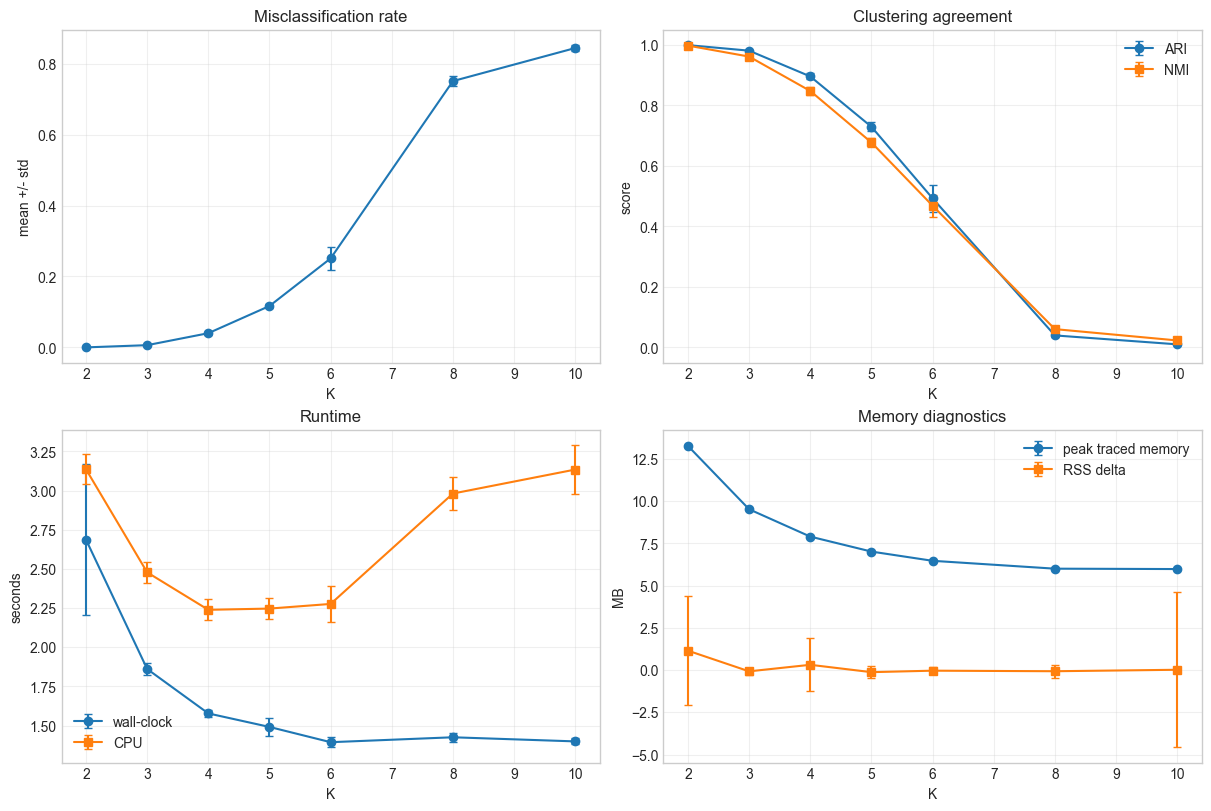

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian_summary.png')

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["K"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["wall_clock_sec_mean"], yerr=summary["wall_clock_sec_std"].fillna(0.0), marker="o", capsize=3, label="wall-clock")
axes[1, 0].errorbar(x, summary["cpu_time_sec_mean"], yerr=summary["cpu_time_sec_std"].fillna(0.0), marker="s", capsize=3, label="CPU")
axes[1, 0].set_title("Runtime")
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(
    x,
    summary["peak_traced_memory_mb_mean"],
    yerr=summary["peak_traced_memory_mb_std"].fillna(0.0),
    marker="o",
    capsize=3,
    label="peak traced memory",
)
if summary["rss_delta_mb_mean"].notna().any():
    axes[1, 1].errorbar(
        x,
        summary["rss_delta_mb_mean"],
        yerr=summary["rss_delta_mb_std"].fillna(0.0),
        marker="s",
        capsize=3,
        label="RSS delta",
    )
axes[1, 1].set_title("Memory diagnostics")
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("MB")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path

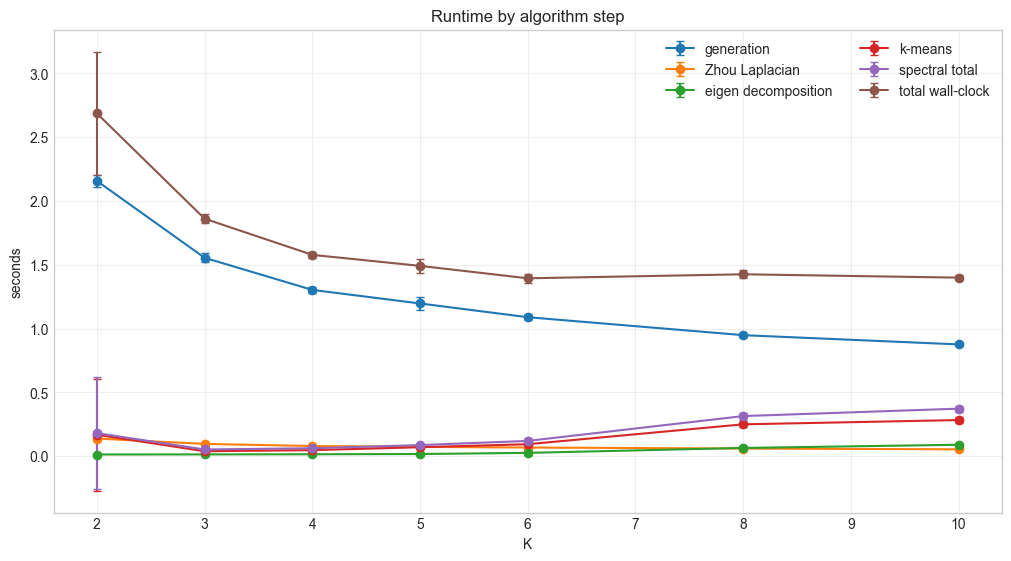

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/메인 실험/results/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian/EXP-20260426-003_nonuniform_hsbm_fixed_n_k_scaling_zhou_laplacian_runtime_breakdown.png')

In [13]:
x = summary["K"].to_numpy()

runtime_series = [
    ("generation_wall_sec", "generation"),
    ("zhou_laplacian_wall_sec", "Zhou Laplacian"),
    ("eigen_decomposition_wall_sec", "eigen decomposition"),
    ("kmeans_wall_sec", "k-means"),
    ("spectral_clustering_wall_sec", "spectral total"),
    ("wall_clock_sec", "total wall-clock"),
]

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for col, label in runtime_series:
    mean_col = f"{col}_mean"
    std_col = f"{col}_std"
    if mean_col not in summary.columns:
        continue
    ax.errorbar(
        x,
        summary[mean_col],
        yerr=summary[std_col].fillna(0.0) if std_col in summary.columns else None,
        marker="o",
        capsize=3,
        label=label,
    )

ax.set_title("Runtime by algorithm step")
ax.set_xlabel("K")
ax.set_ylabel("seconds")
ax.grid(alpha=0.3)
ax.legend(ncols=2)

runtime_breakdown_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_runtime_breakdown.png"
fig.savefig(runtime_breakdown_path, dpi=180, bbox_inches="tight")
plt.show()

runtime_breakdown_path

## Optional: add another K

Uncomment and run this cell to extend the K sweep. The summary cell above will pick it up only if you add the frame name or append it manually.


In [14]:
# df_k12 = run_k_experiment(12)